In [1]:
import pandas as pd
from lightgbm import LGBMRegressor
import numpy as np

In [2]:
df = pd.read_csv('df_mejora_2.csv')

In [3]:
#df["provincia"] = df["provincia"].astype("category")
#df["hospital"] = df["hospital"].astype("category")
#df["dia_semana"] = df["dia_semana"].astype("category")

df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])
df = df.sort_values("fecha_hora")

df["hora"] = df["fecha_hora"].dt.hour
df["dia"] = df["fecha_hora"].dt.day
df["mes"] = df["fecha_hora"].dt.month
df["año"] = df["fecha_hora"].dt.year

df["lag_1"] = df["target_pacientes"].shift(1)
df["lag_24"] = df["target_pacientes"].shift(24)

df["rolling_24"] = df["target_pacientes"].rolling(24).mean()

df = df.dropna()

features = [
    "provincia",
    "hospital",
    "dia_semana",
    "mes",
    "year",
    "hora",
    "temperatura_media",
    "temperatura_maxima",
    "temperatura_minima",
    "precipitaciones",
    "humedad",
    "viento",
    "viento_maximo",
    "pacientes_ayer",
    "lag_1",
    "lag_24",
    "rolling_24"
]

X = df[features]
y = df["target_pacientes"]

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train[features]
X_test = test[features]

y_train = train["target_pacientes"]
y_test = test["target_pacientes"]

fecha_test = test["fecha_hora"]

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2424
[LightGBM] [Info] Number of data points in the train set: 367119, number of used features: 17
[LightGBM] [Info] Start training from score 371.224538


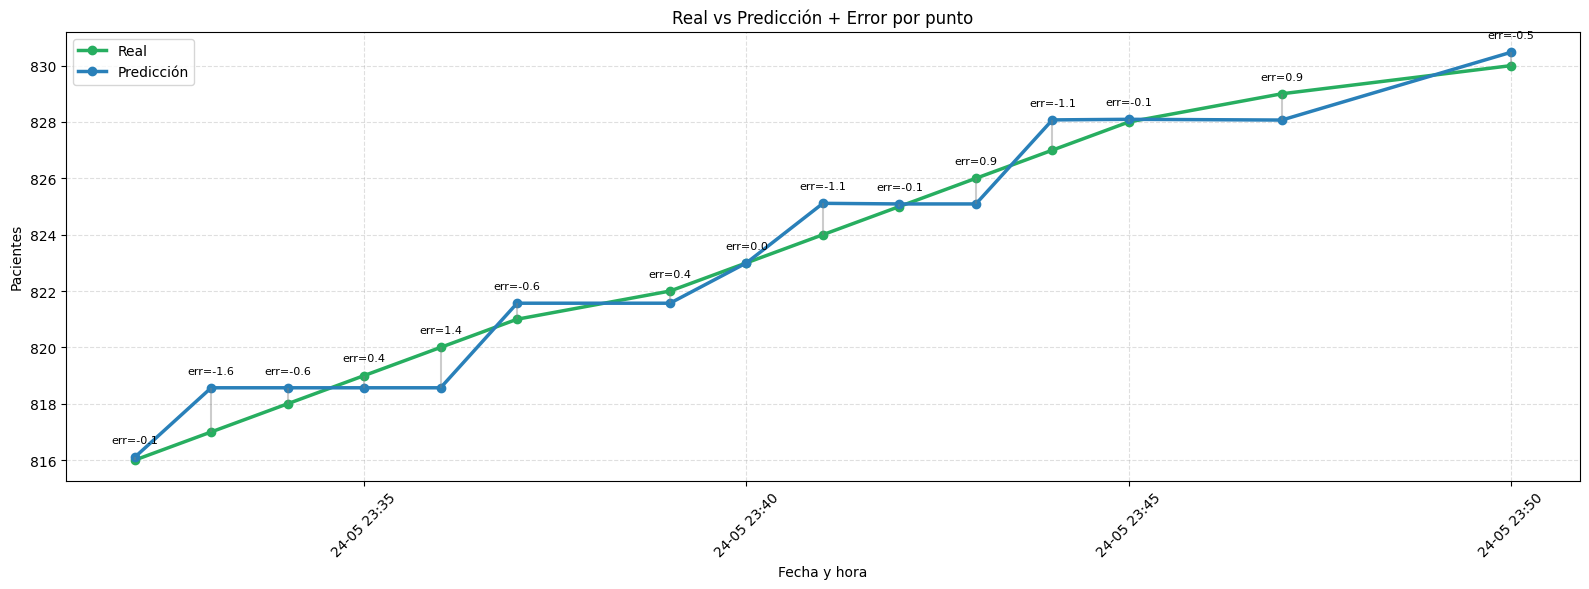

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import pandas as pd

n = 15

x = pd.to_datetime(fecha_test.iloc[:n])
y_real = y_test.iloc[:n].values
y_pred = pred[:n]

error = y_real - y_pred

plt.figure(figsize=(16, 6))

# Real y predicción
plt.plot(x, y_real, marker='o', linewidth=2.5, label='Real', color='#27ae60')
plt.plot(x, y_pred, marker='o', linewidth=2.5, label='Predicción', color='#2980b9')

# Línea de error punto a punto
for i in range(n):
    plt.vlines(x.iloc[i], y_real[i], y_pred[i], color='gray', alpha=0.4)

# Texto del error en cada punto
for i in range(n):
    plt.text(
        x.iloc[i],
        max(y_real[i], y_pred[i]) + 0.5,
        f"err={error[i]:.1f}",
        ha='center',
        fontsize=8
    )

# Formato eje X con fecha + hora
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)

plt.title("Real vs Predicción + Error por punto")
plt.xlabel("Fecha y hora")
plt.ylabel("Pacientes")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import joblib

joblib.dump(model, "modelo_lightgbm.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']